<a href="https://colab.research.google.com/github/OJB-Quantum/Onris-Bezier-Approximation/blob/main/Piecewise_cubic_bernstein_large_numbers_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Piecewise cubic Bernstein fits for five dramatic large-number examples

This adapts the custom anchor-based composite Bézier method. Each Bézier span is a cubic Bernstein polynomial, so the overall surrogate is a piecewise Bernstein approximation.

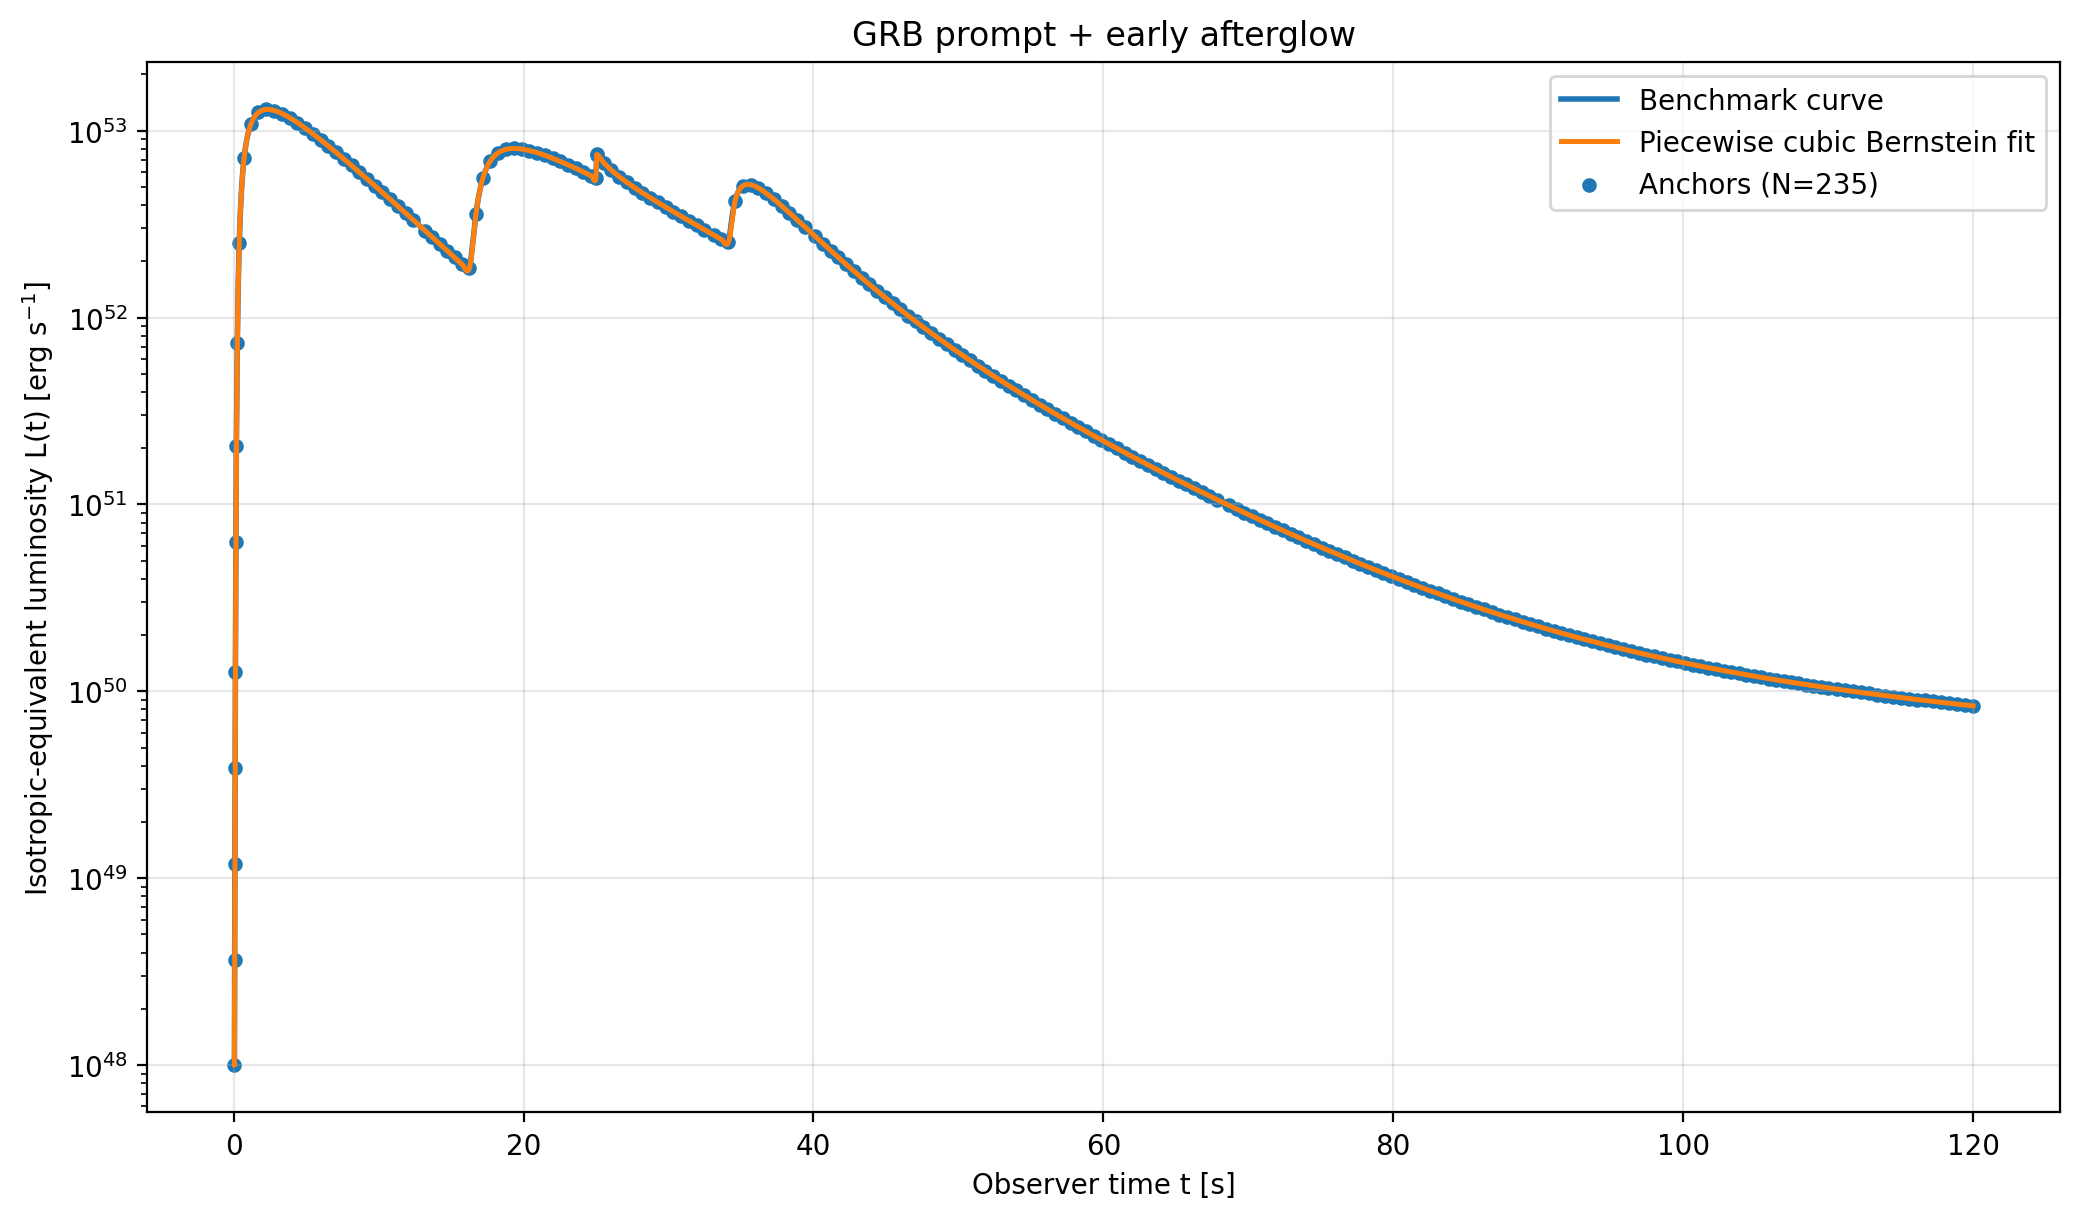

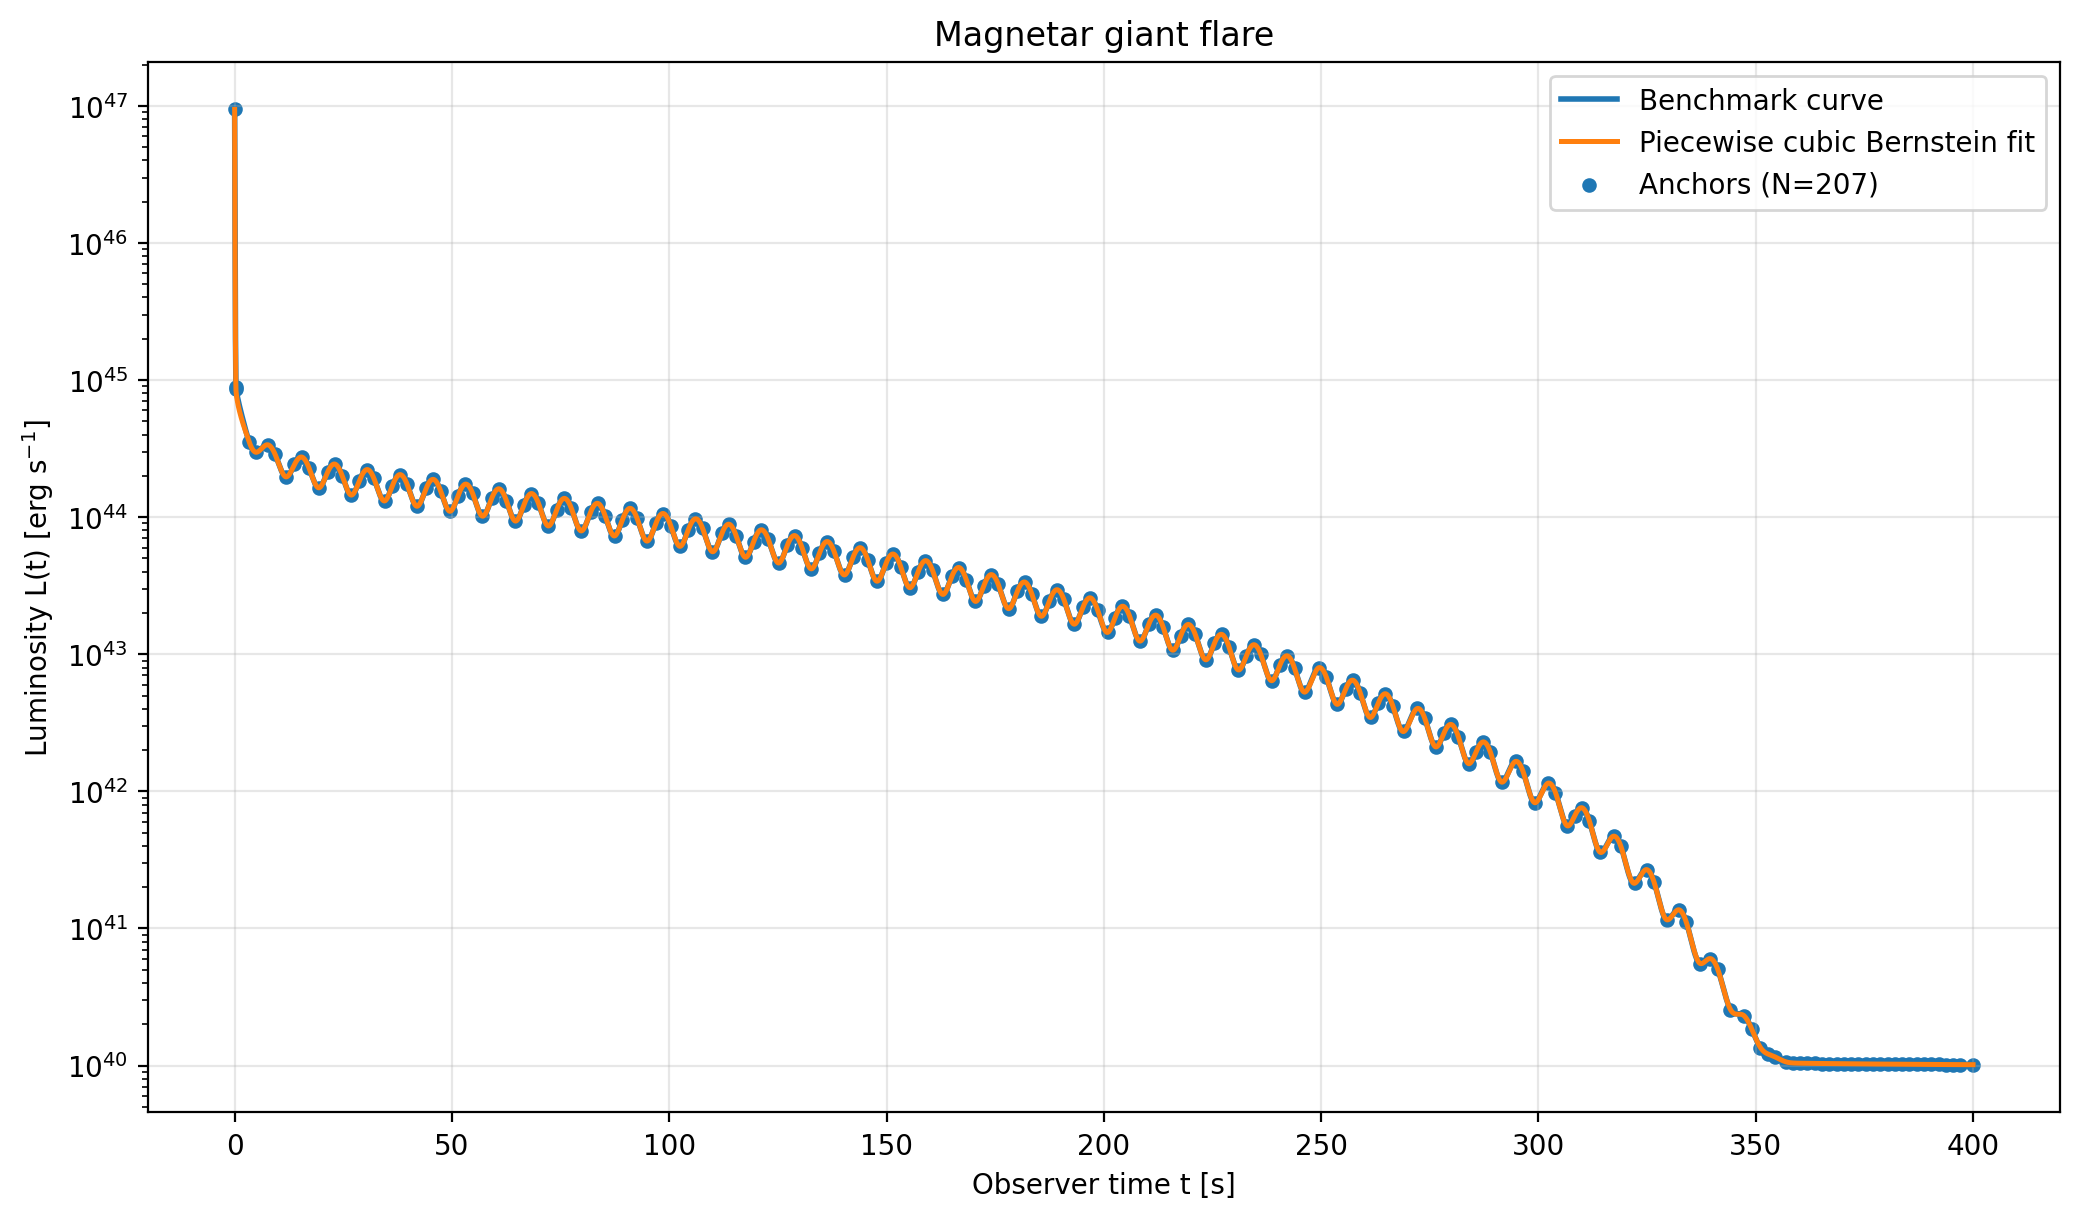

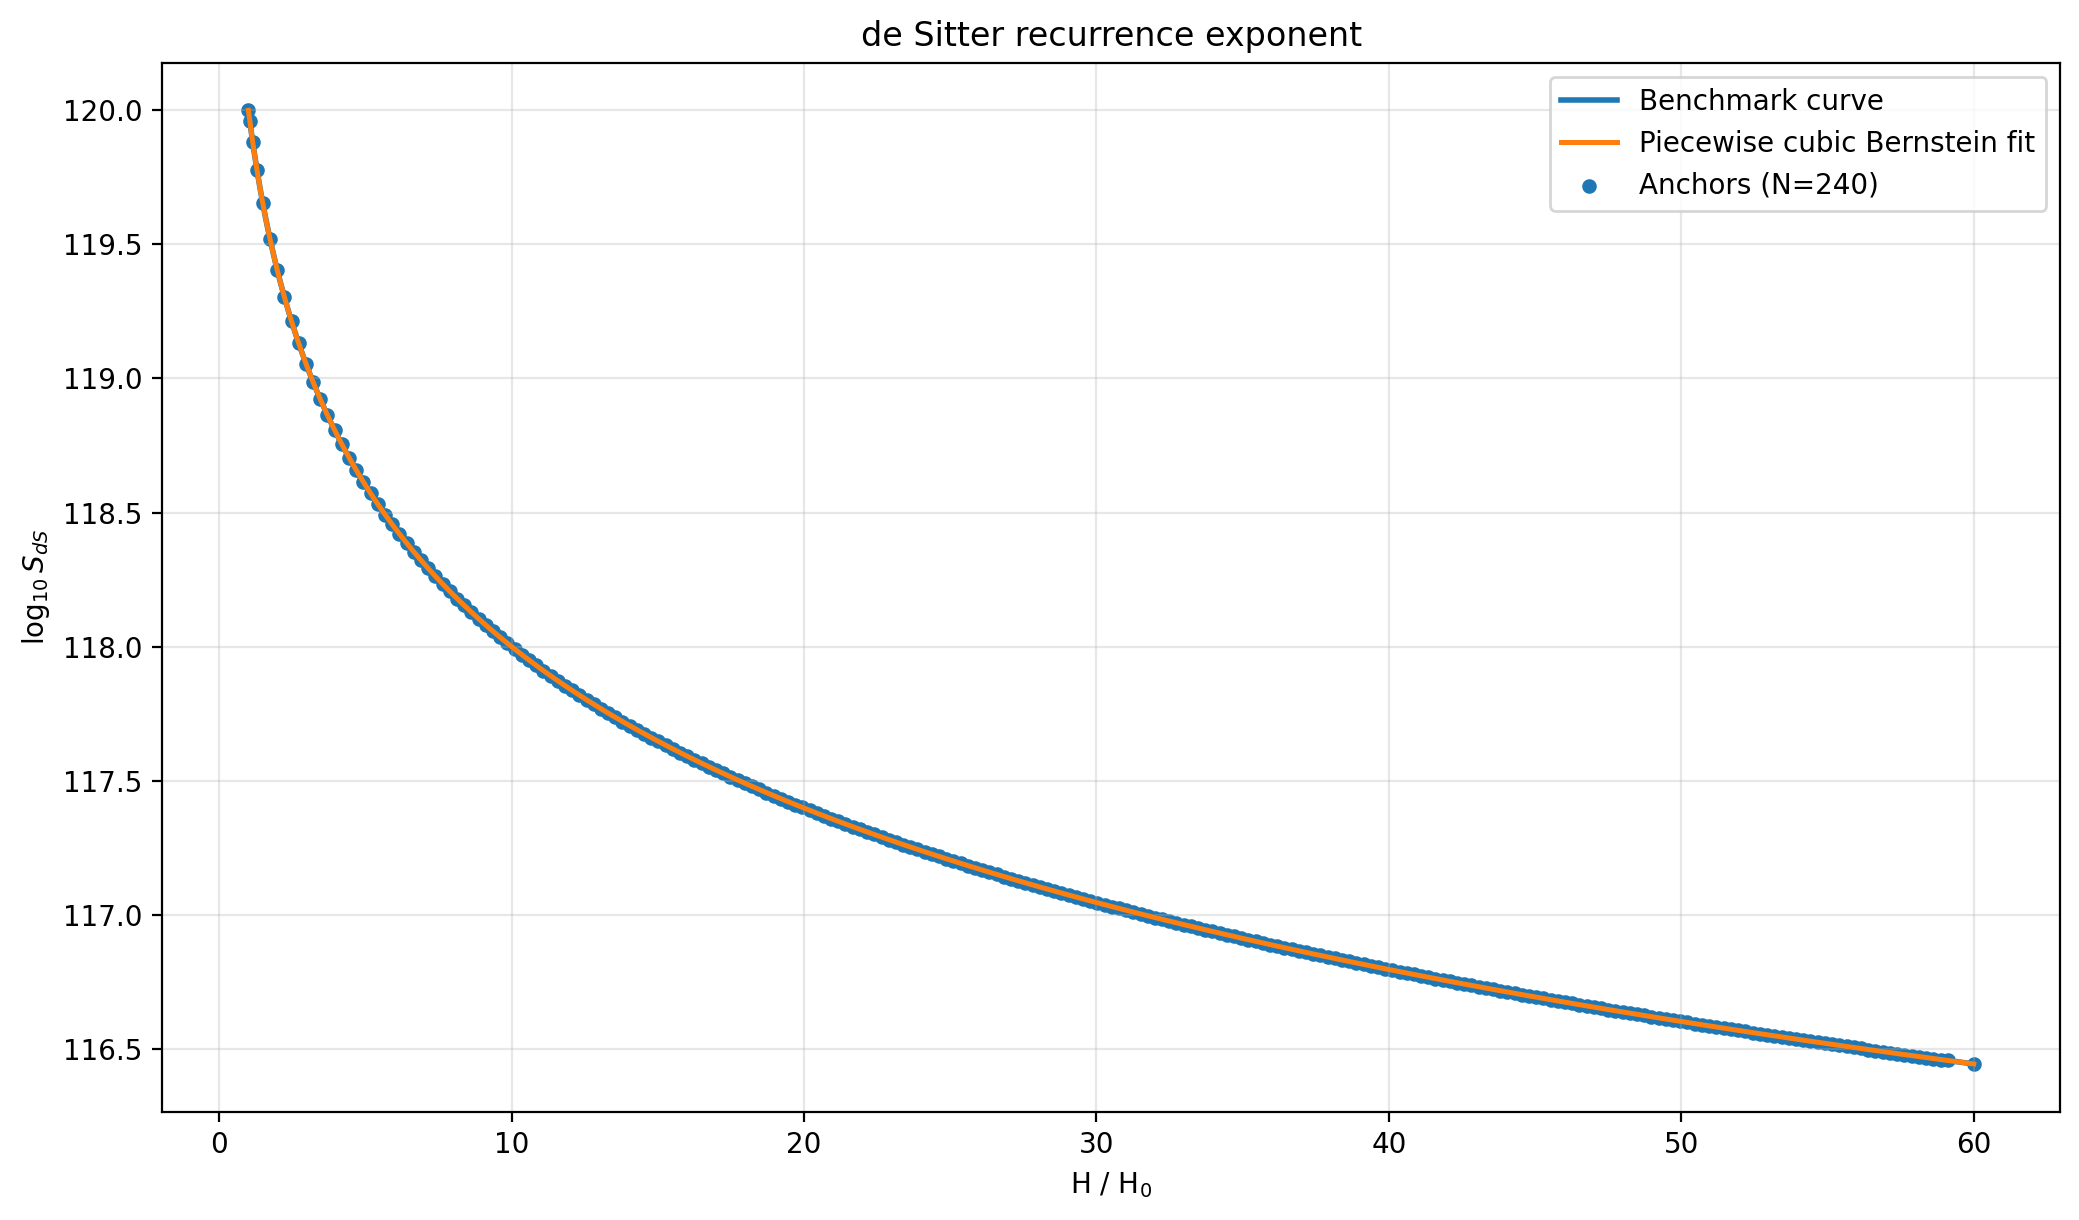

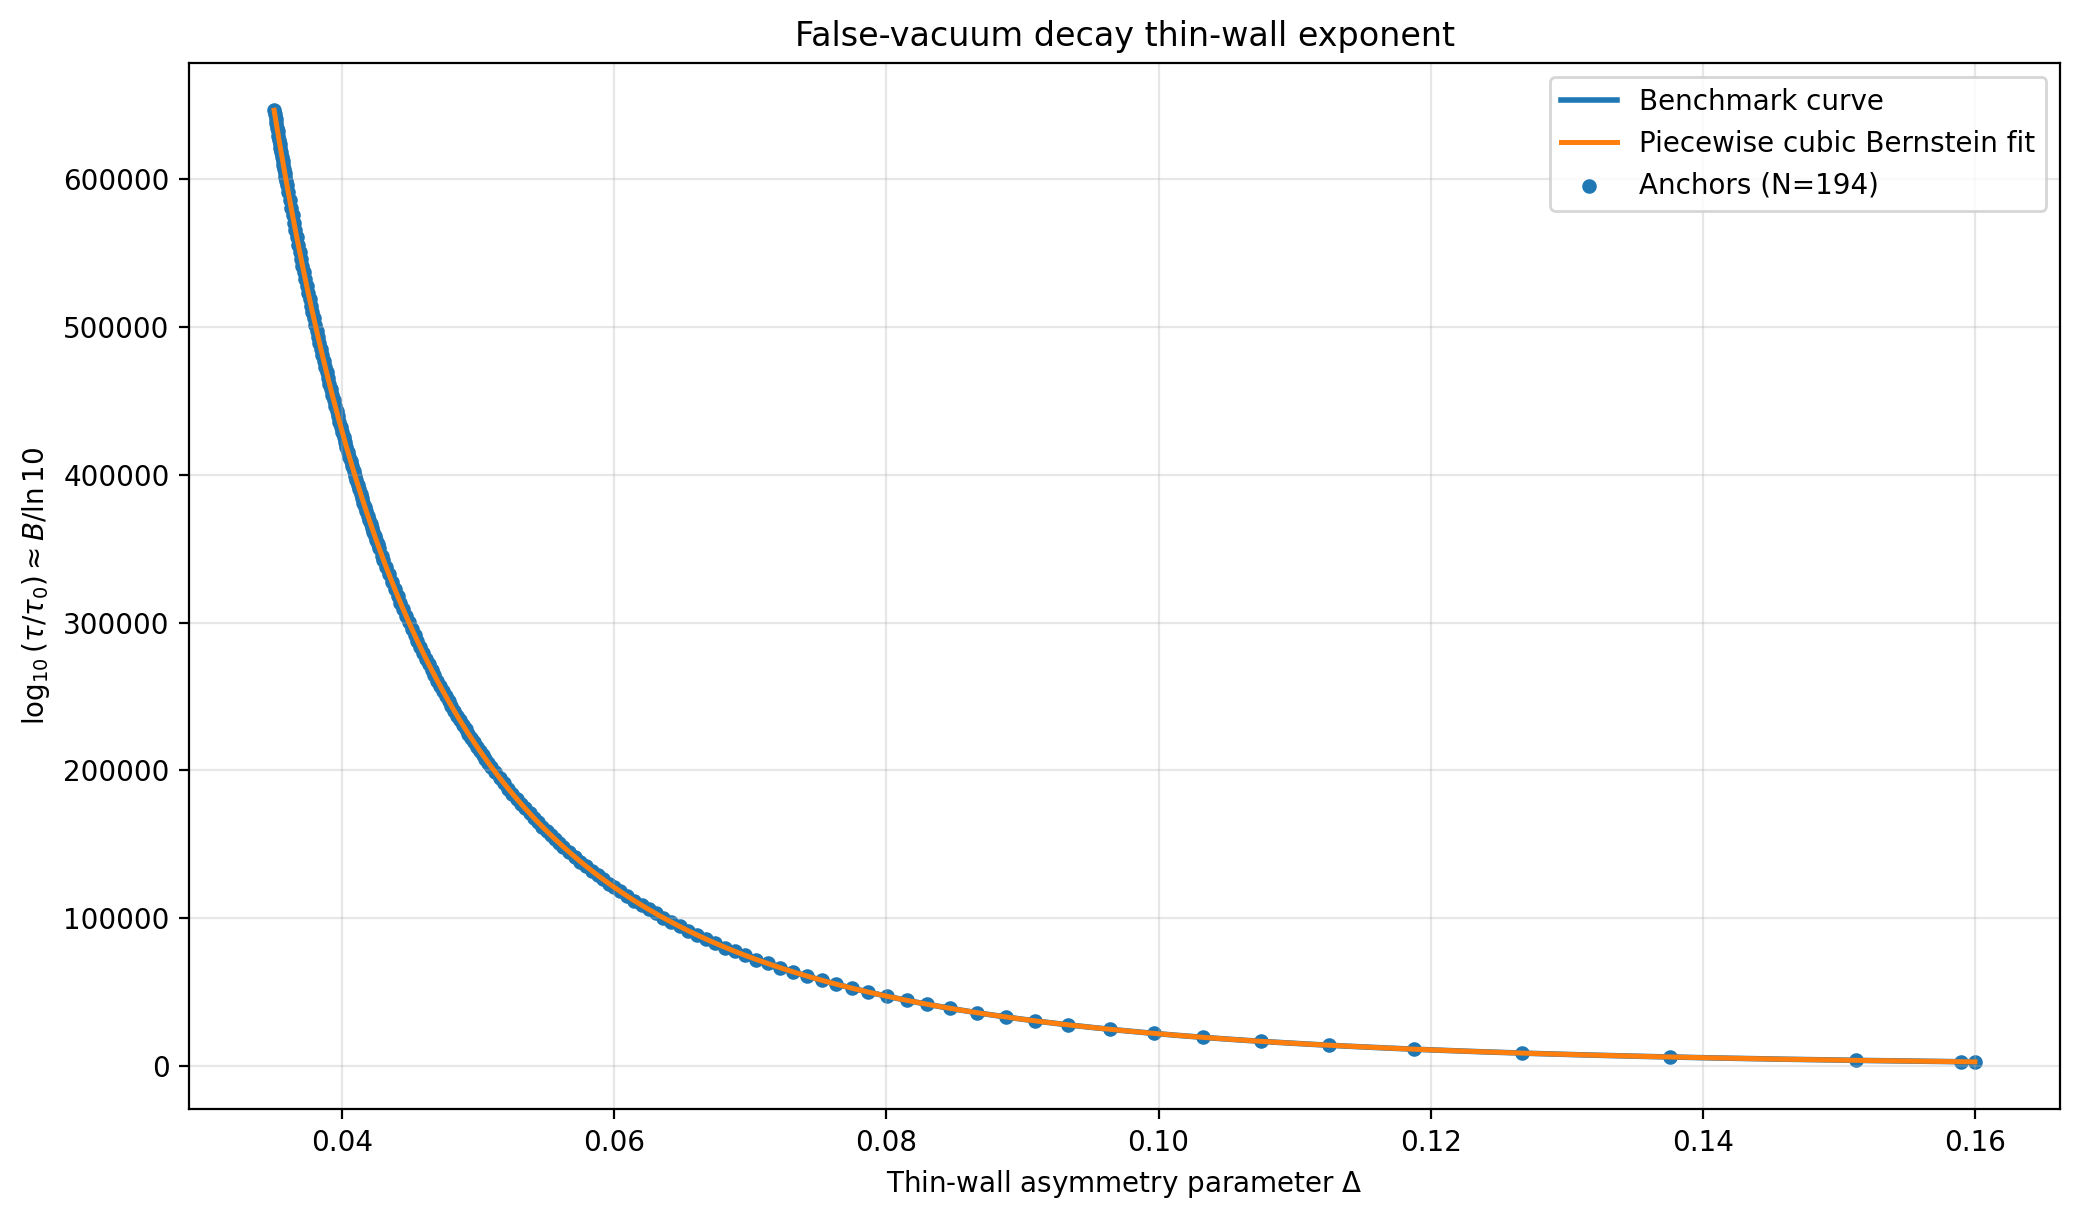

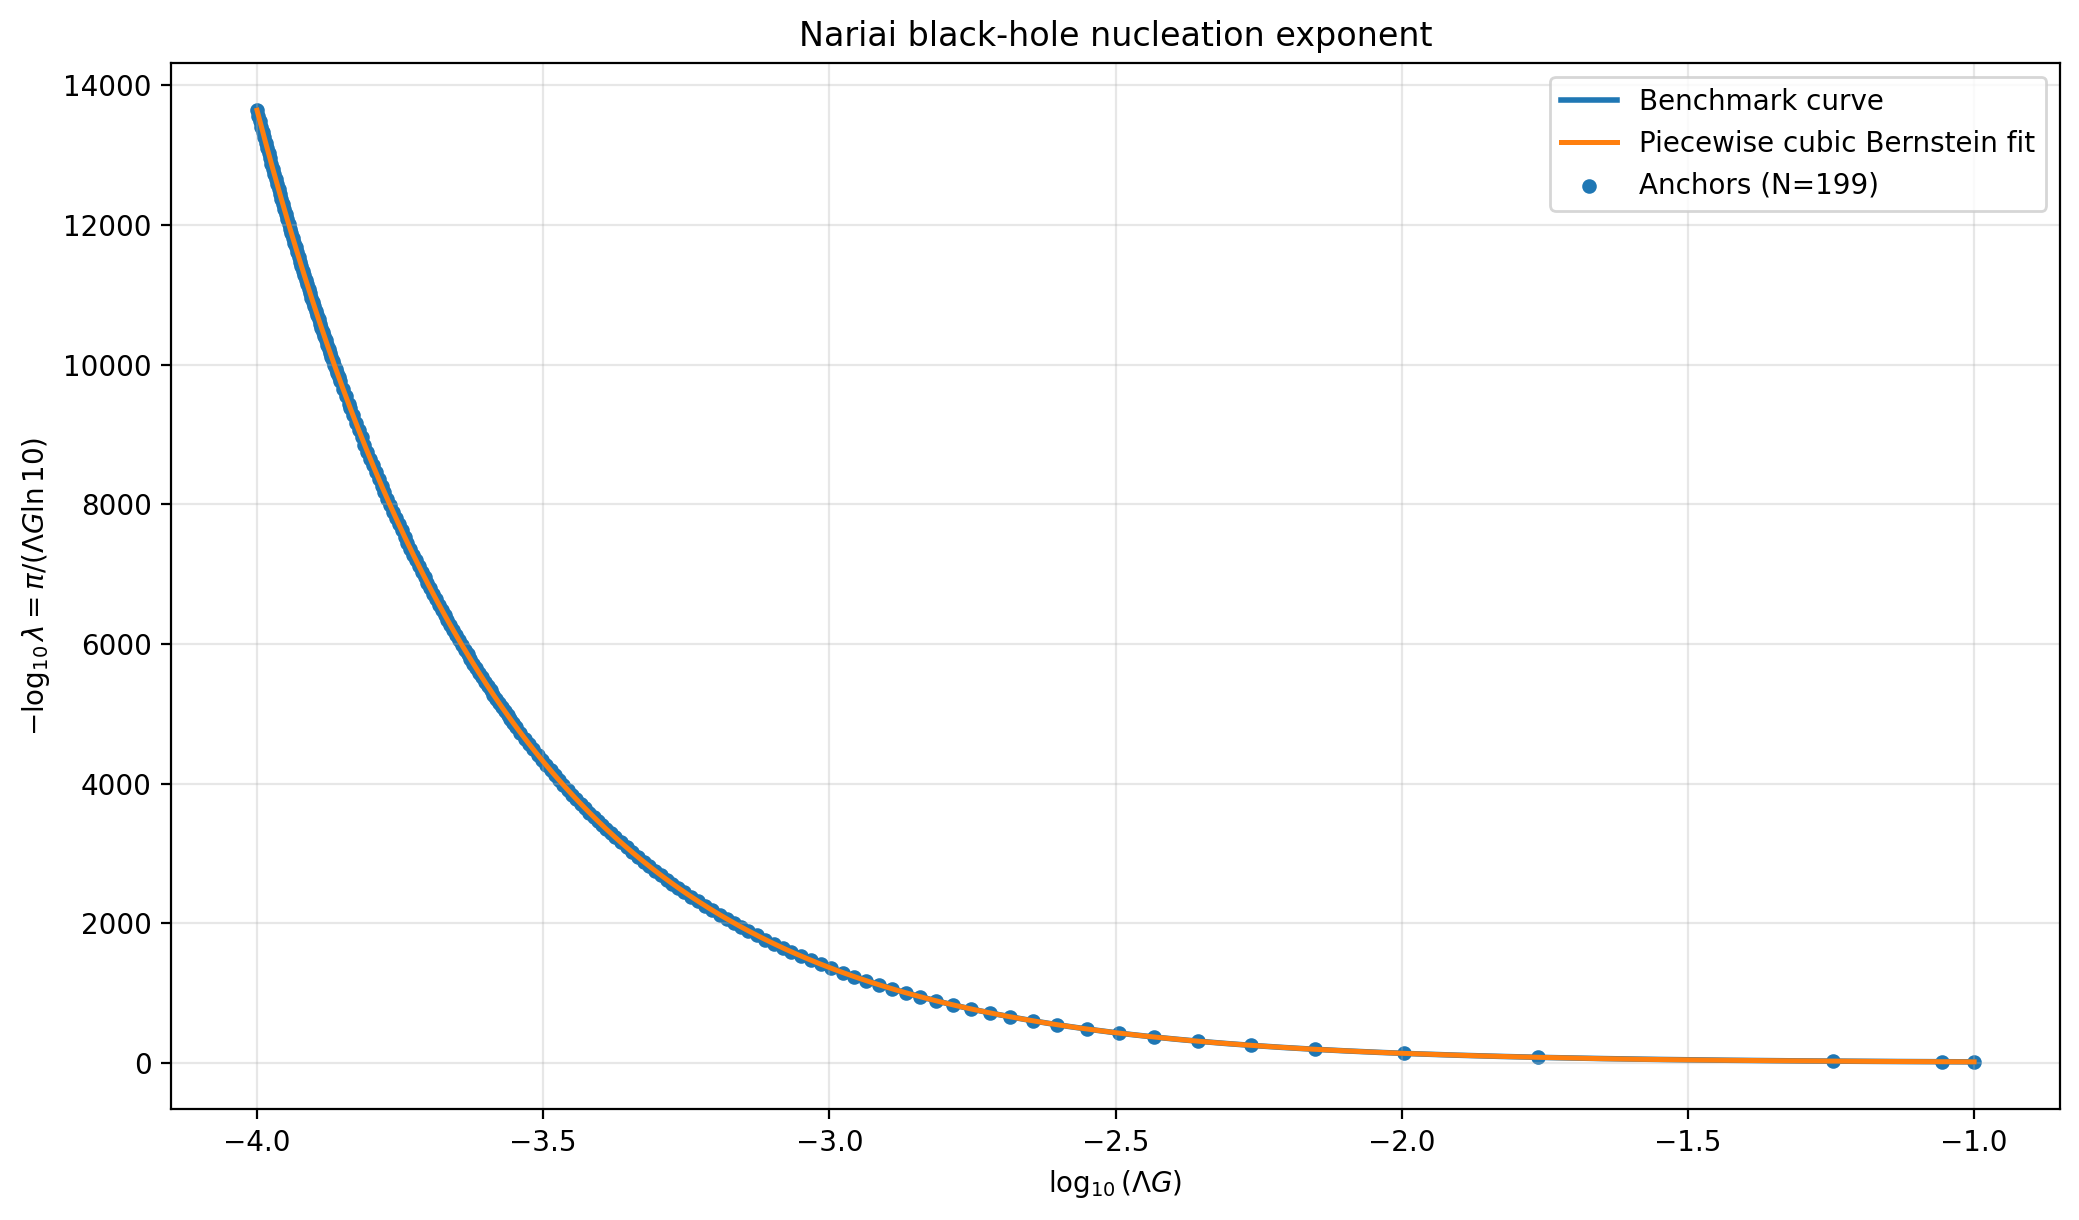

## GRB prompt + early afterglow


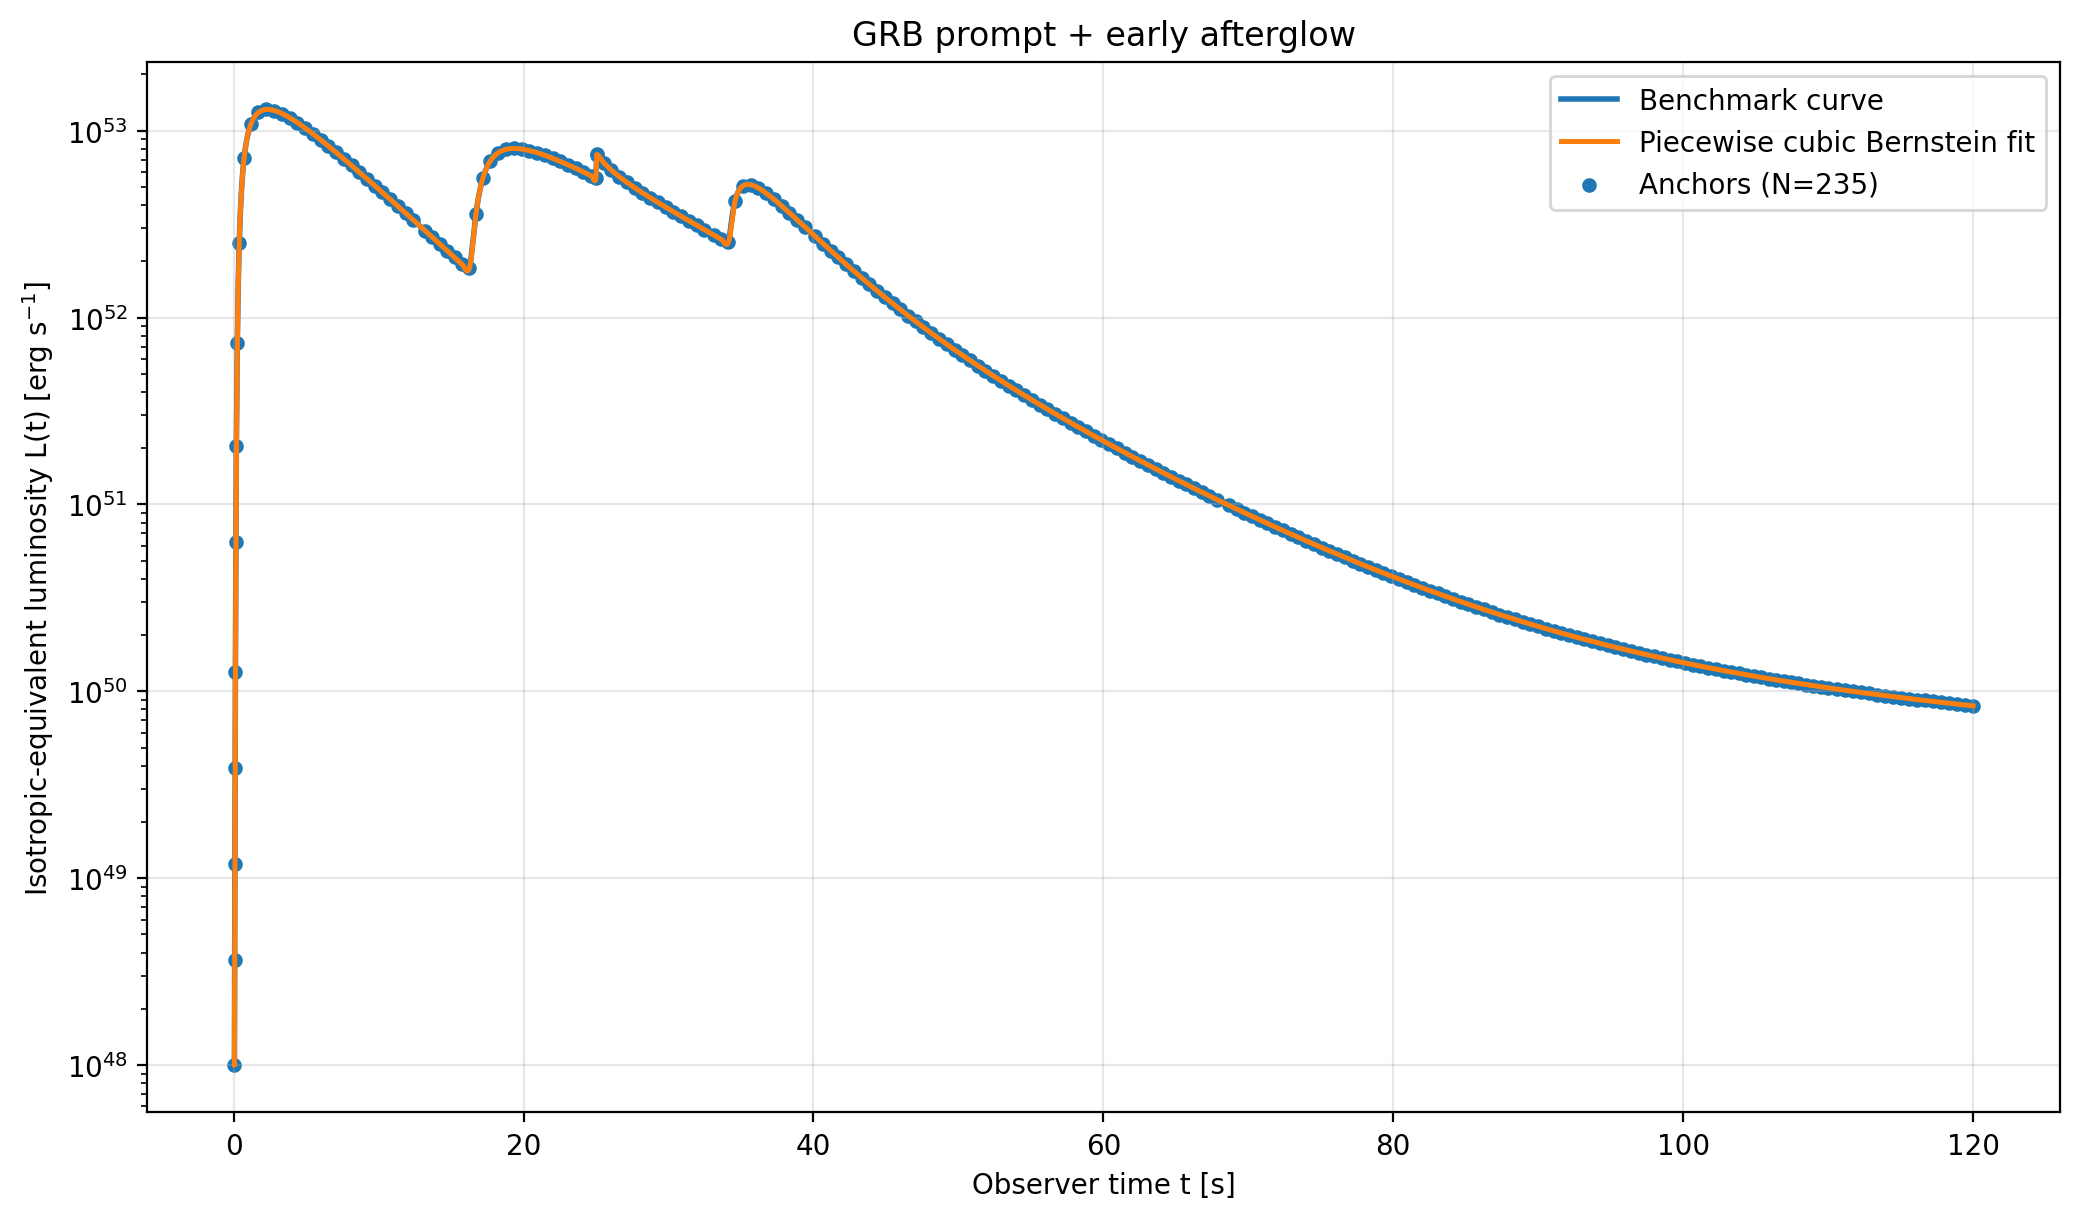

{'max_abs_error': 0.019695098759690666, 'rmse': 0.001347140107031406, 'max_relative_error': 0.0003751310570344937, 'mean_relative_error': 3.28815602084128e-06}
{'max_abs_error': 2.128340321813514e+51, 'rmse': 1.1166657399183495e+50, 'max_relative_error': 0.044336559916159965, 'mean_relative_error': 0.0003930566050001774}

## Magnetar giant flare


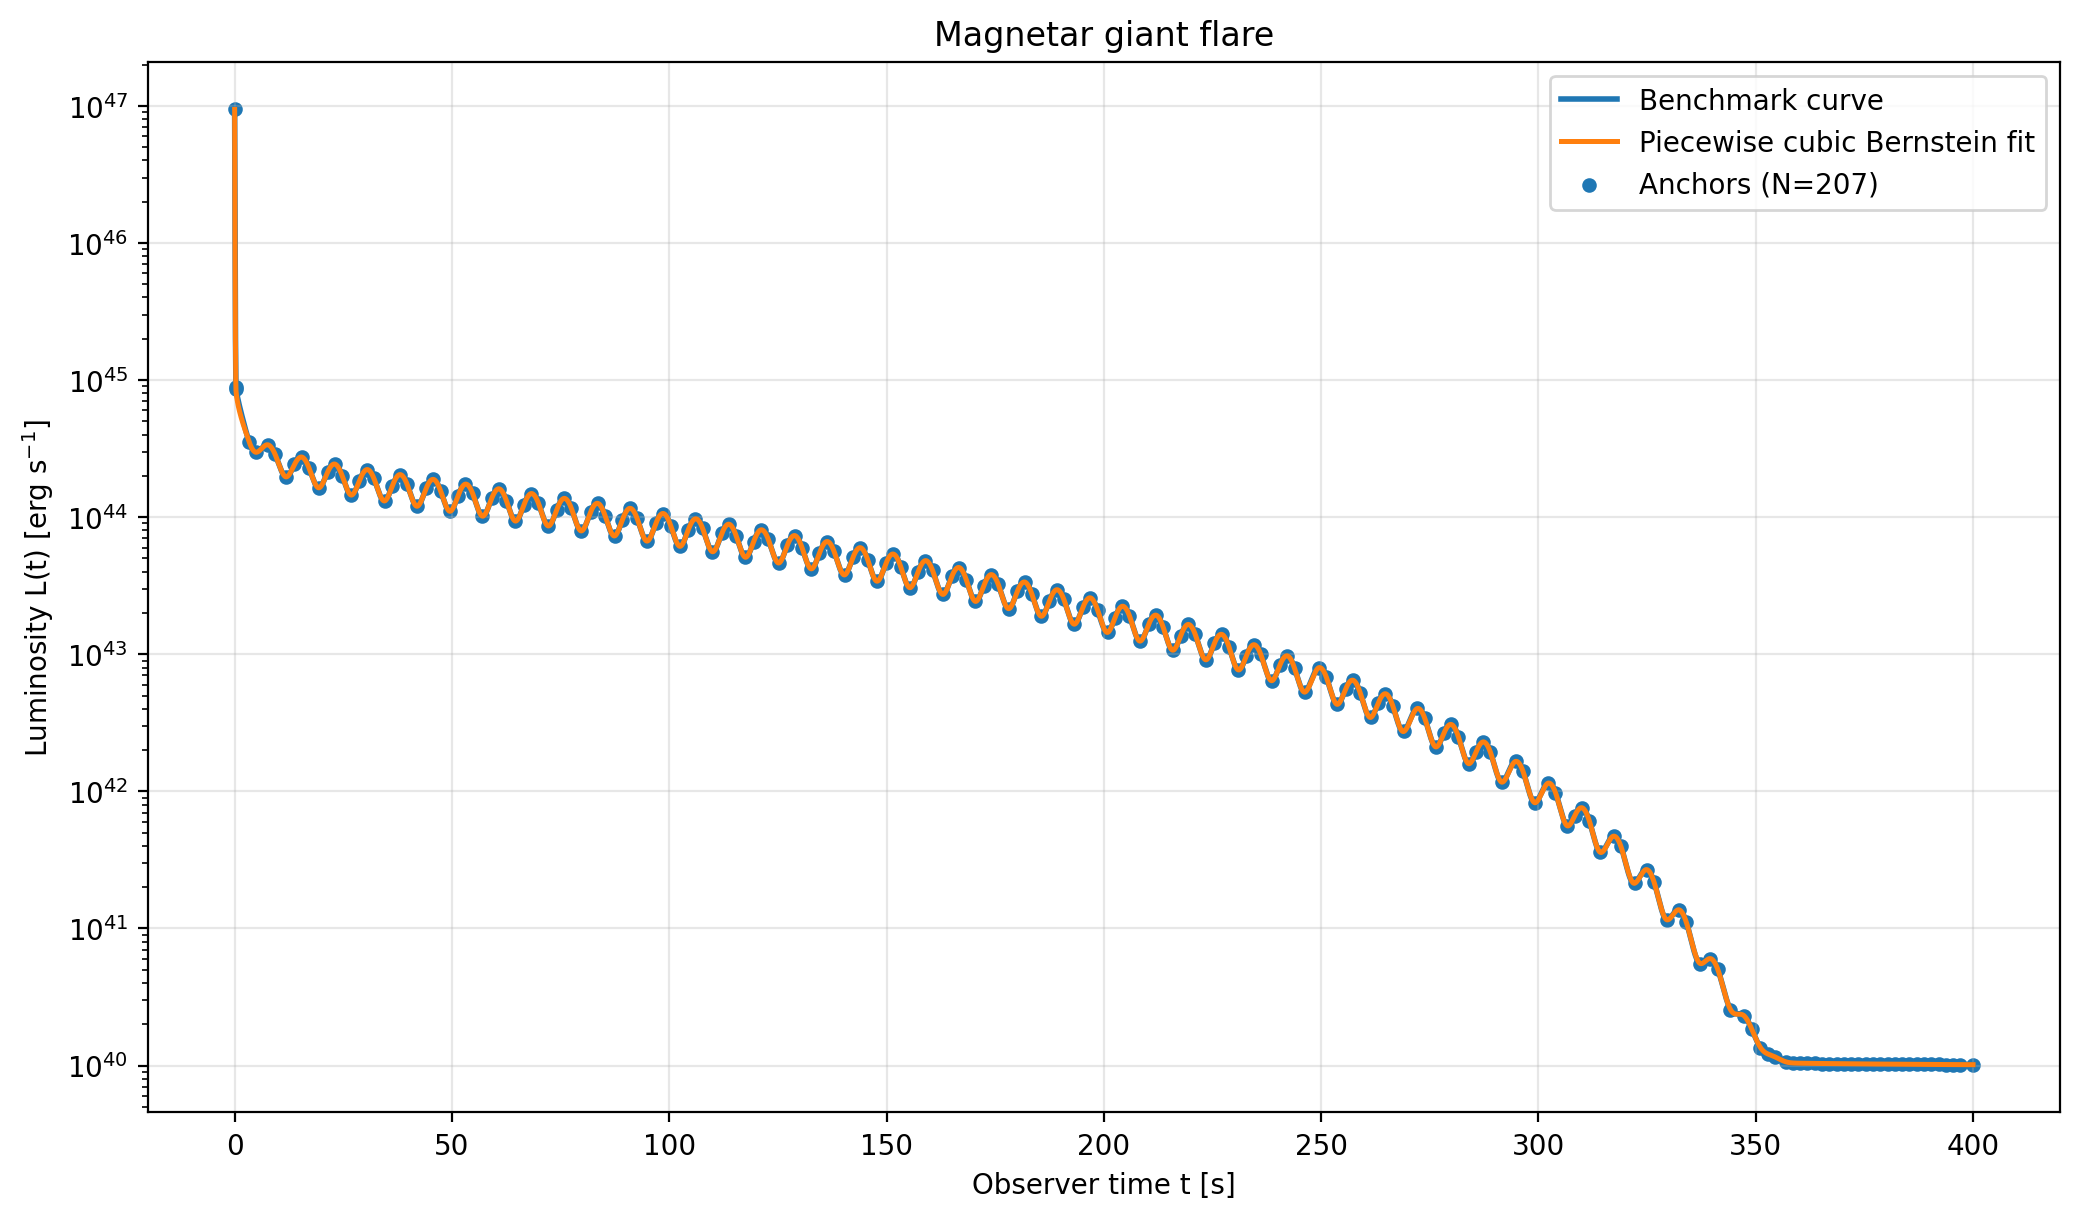

{'max_abs_error': 0.24784631722648243, 'rmse': 0.004877150952216595, 'max_relative_error': 0.00536818978958803, 'mean_relative_error': 1.8189543326809872e-05}
{'max_abs_error': 6.423516972816963e+45, 'rmse': 1.0178927448937781e+44, 'max_relative_error': 0.4348432388514845, 'mean_relative_error': 0.0017635742836801956}

## de Sitter recurrence exponent


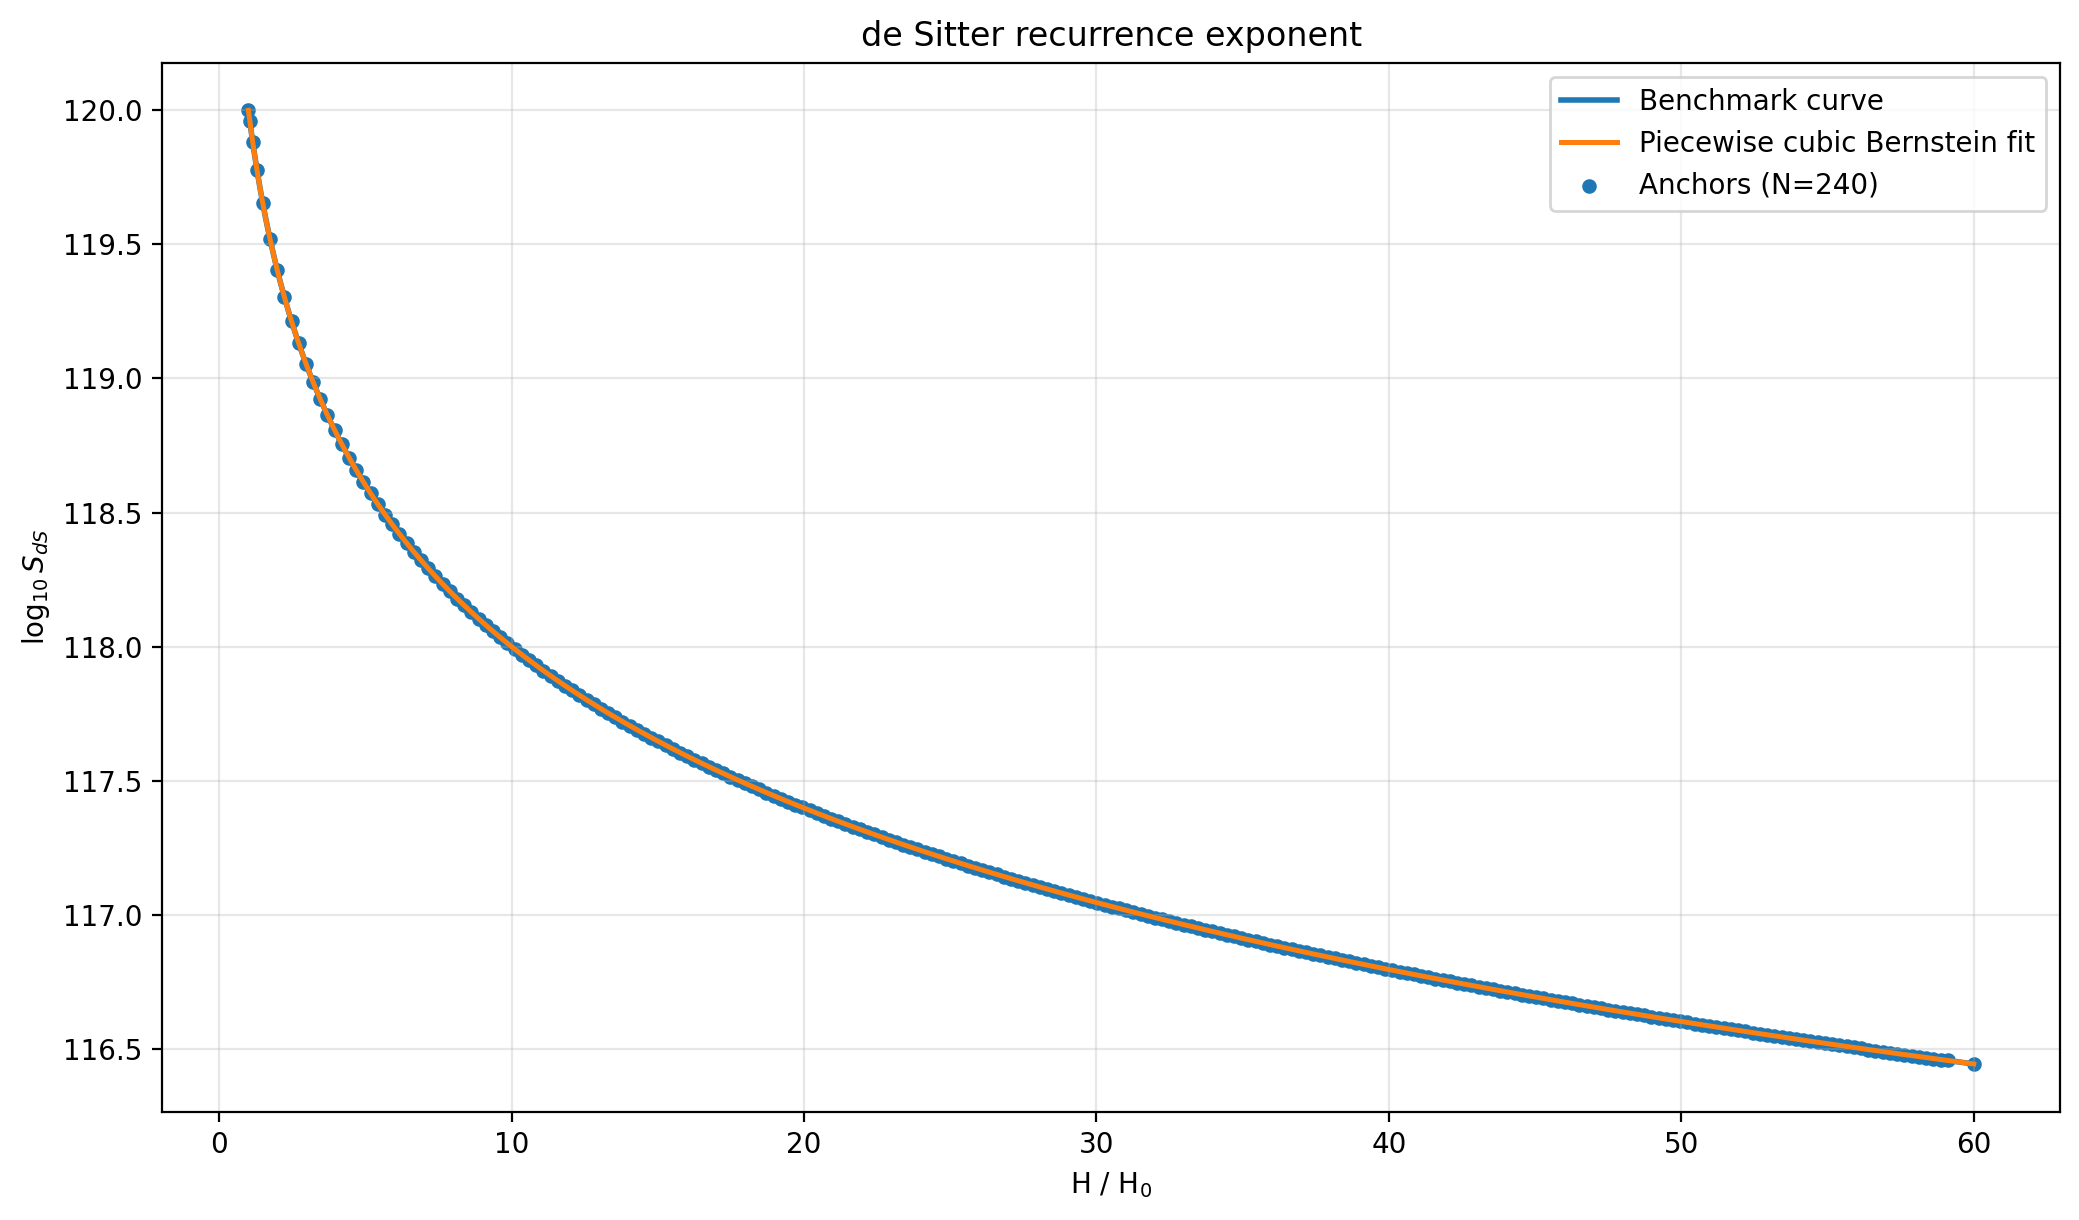

{'max_abs_error': 6.701486154270242e-05, 'rmse': 3.963953936280204e-06, 'max_relative_error': 5.596562042713812e-07, 'mean_relative_error': 4.149750079812545e-09}
{'max_abs_error': 6.701486154270242e-05, 'rmse': 3.963953936280204e-06, 'max_relative_error': 5.596562042713812e-07, 'mean_relative_error': 4.149750079812545e-09}

## False-vacuum decay thin-wall exponent


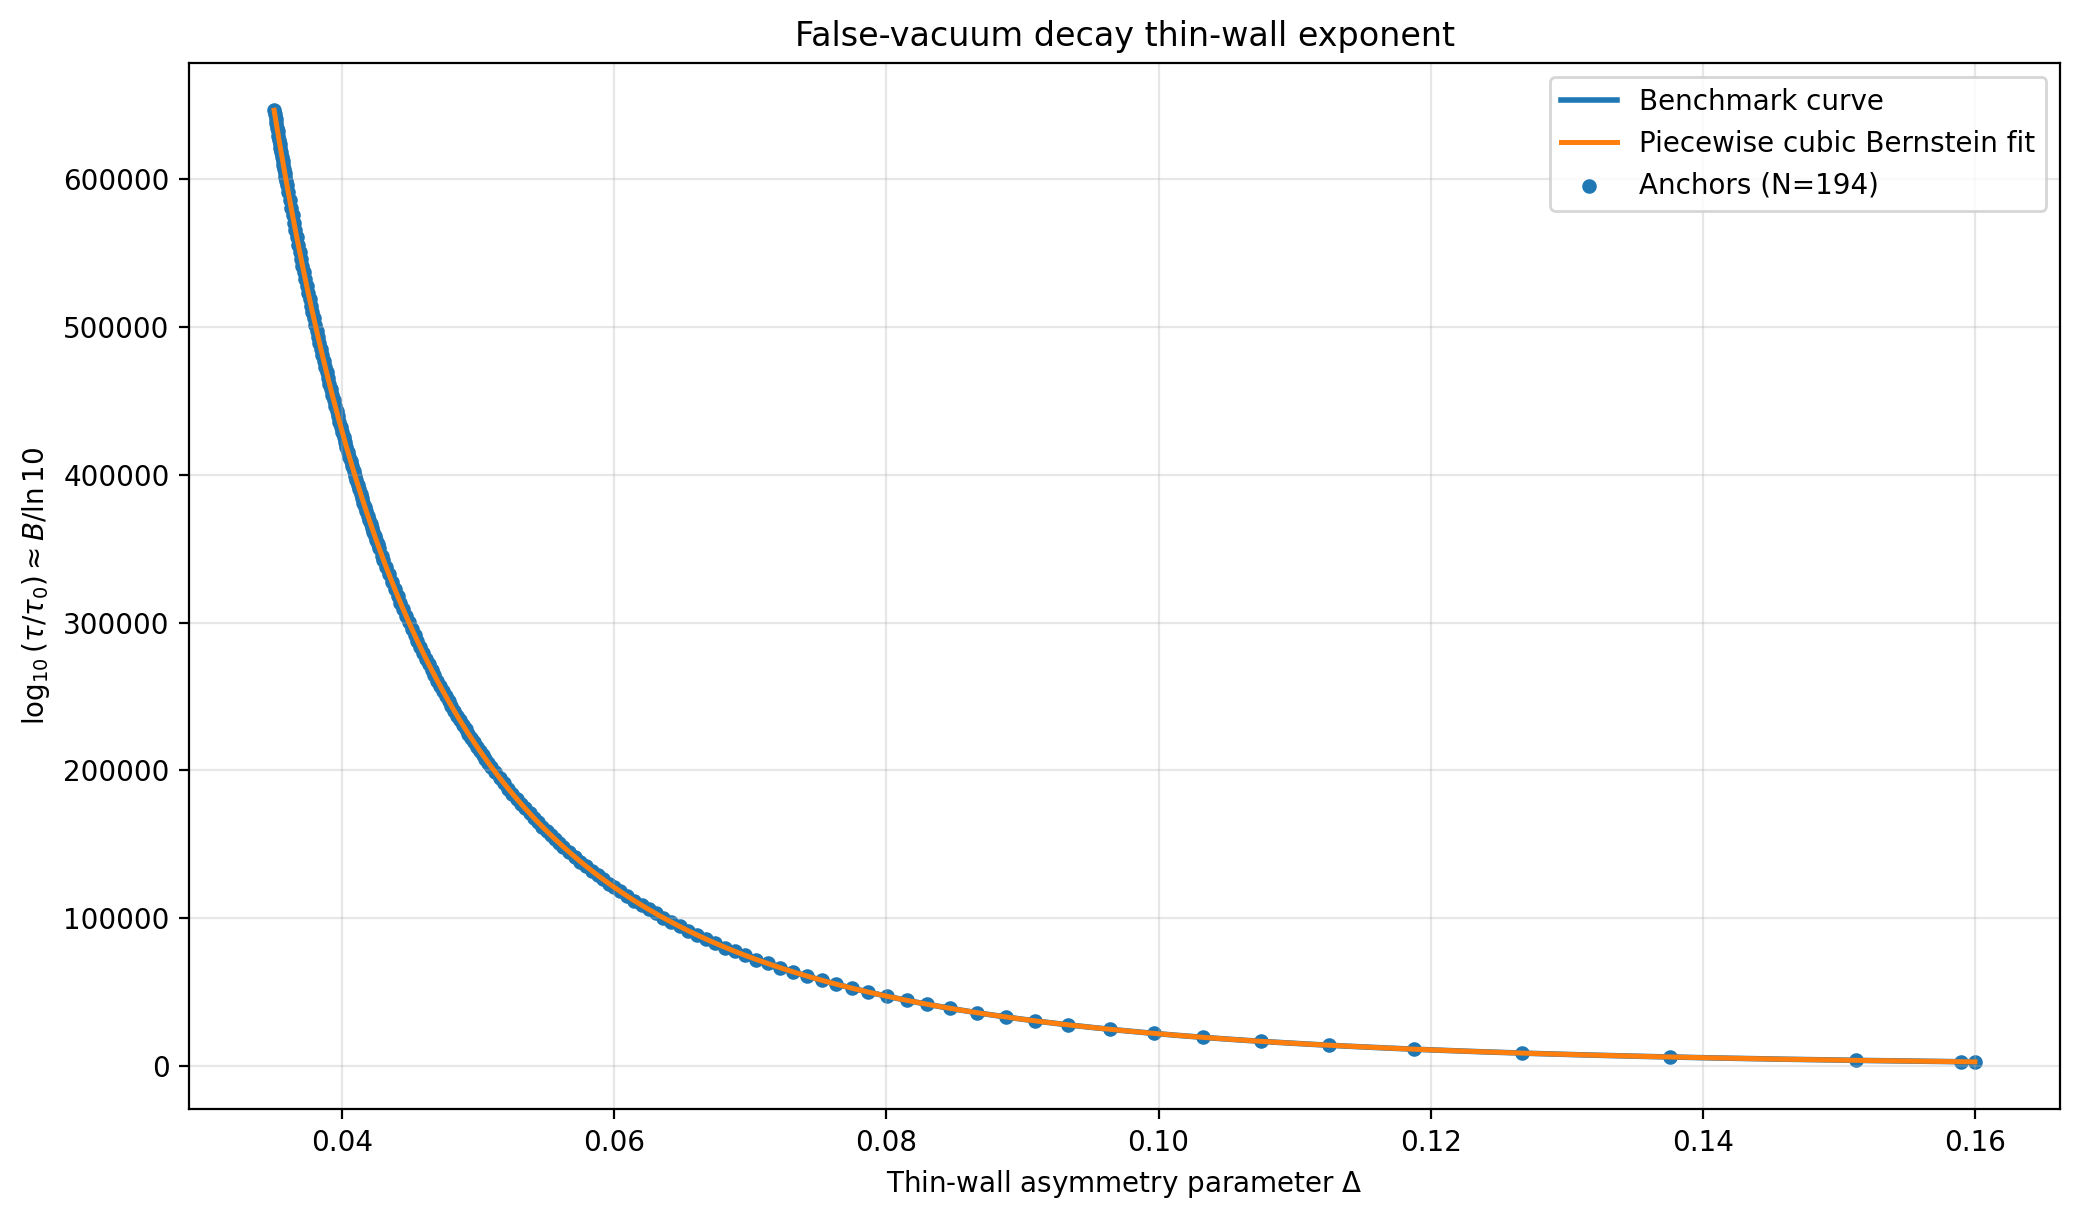

{'max_abs_error': 5.935942113981582, 'rmse': 0.8766161752609634, 'max_relative_error': 0.0004316942831743995, 'mean_relative_error': 4.2756176989550296e-05}
{'max_abs_error': 5.935942113981582, 'rmse': 0.8766161752609634, 'max_relative_error': 0.0004316942831743995, 'mean_relative_error': 4.2756176989550296e-05}

## Nariai black-hole nucleation exponent


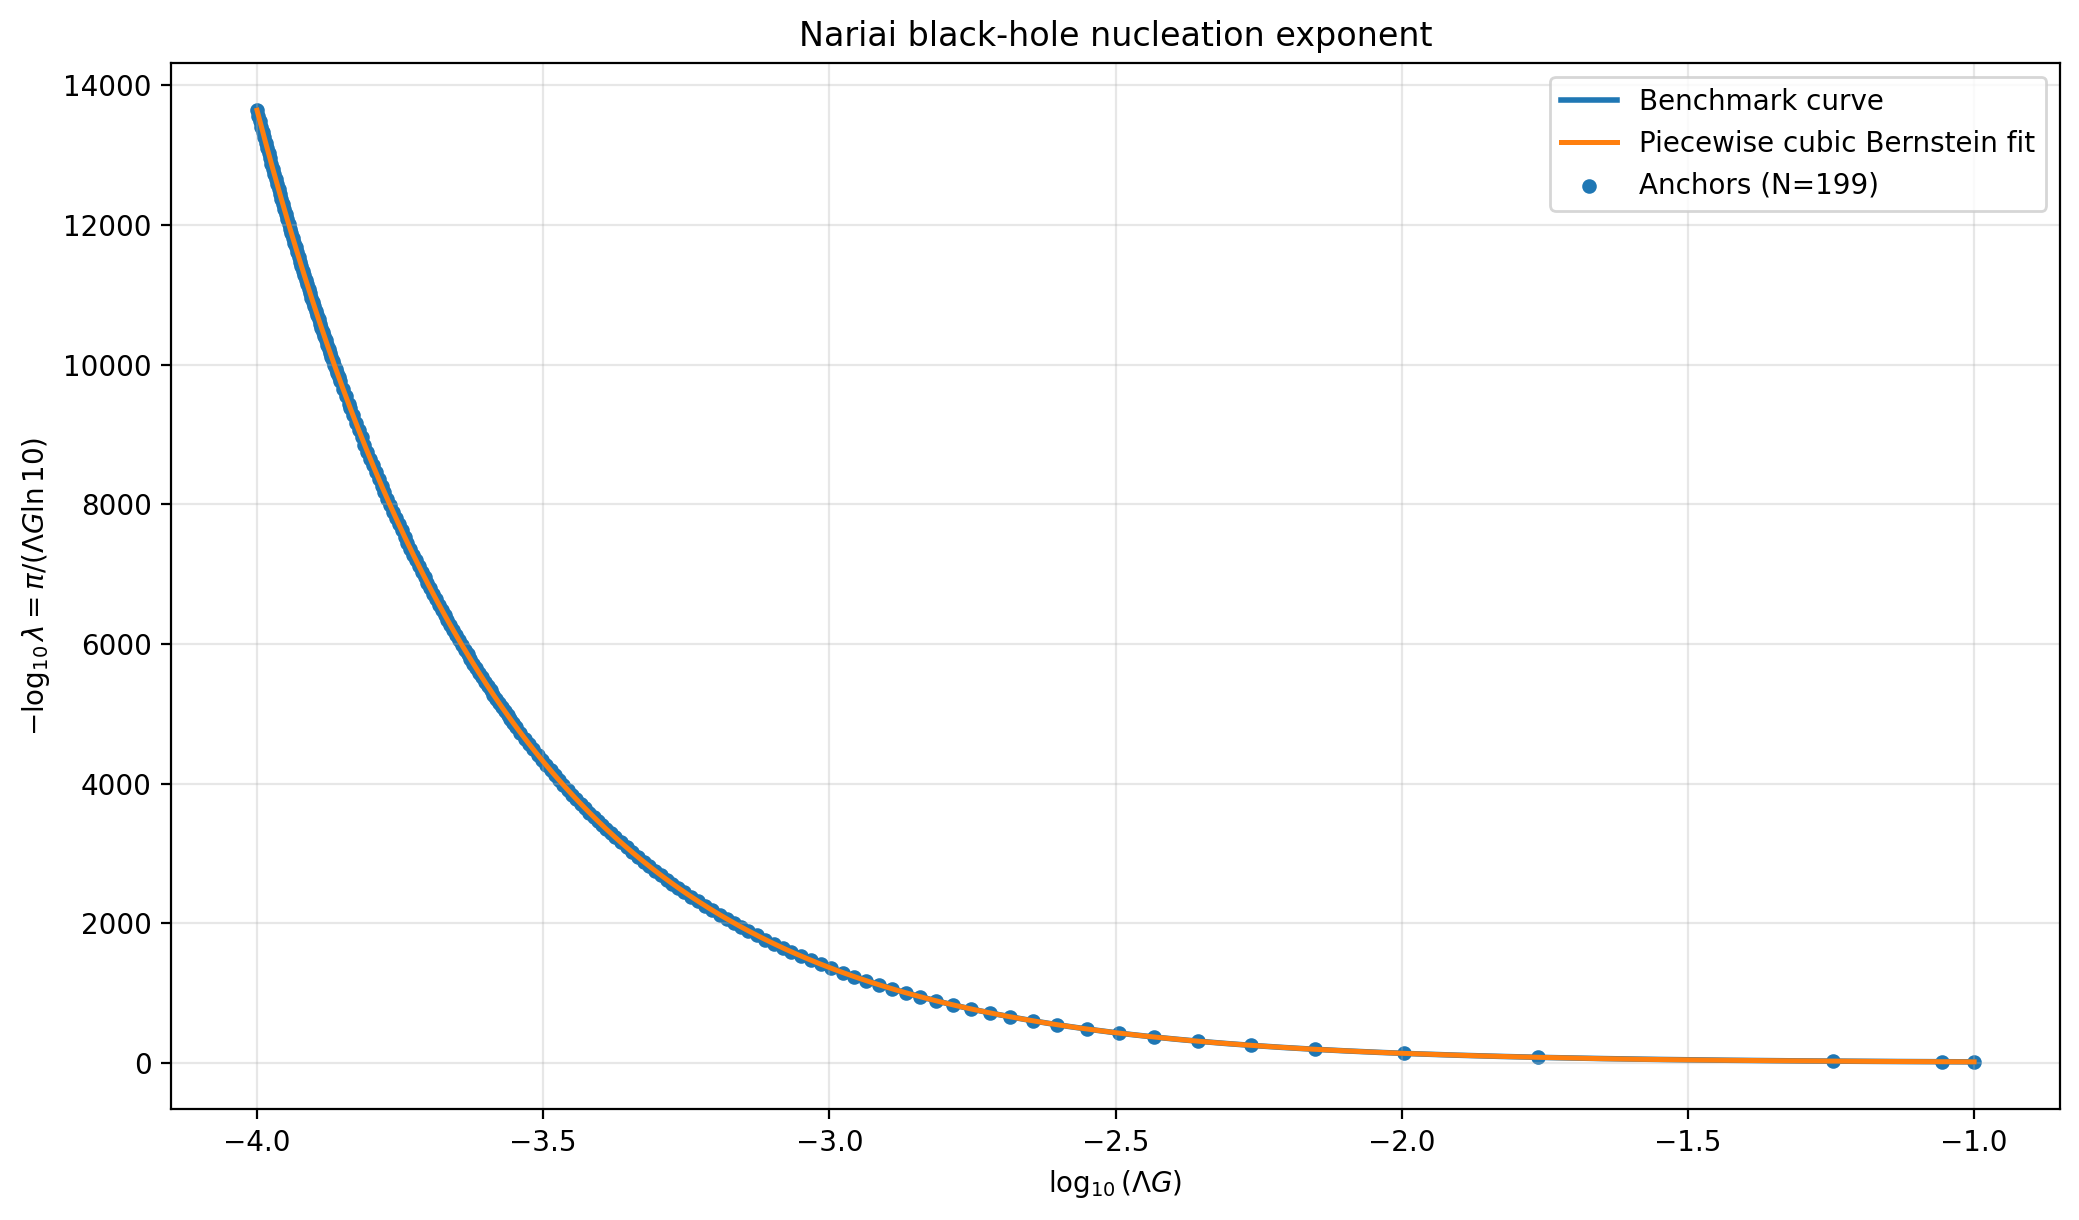

{'max_abs_error': 1.6388536339622988, 'rmse': 0.408593607771267, 'max_relative_error': 0.03159429914752009, 'mean_relative_error': 0.0029368052308671455}
{'max_abs_error': 1.6388536339622988, 'rmse': 0.408593607771267, 'max_relative_error': 0.03159429914752009, 'mean_relative_error': 0.0029368052308671455}


In [10]:
# -*- coding: utf-8 -*-
"""Colab-ready piecewise cubic Bernstein fits for five dramatic large-number examples.

This script adapts the custom anchor-based composite Bezier method.
Each Bezier span is a cubic Bernstein polynomial, so the overall surrogate is a
piecewise Bernstein approximation.

For high-dynamic-range observables, such as GRB and magnetar luminosities, the
fit is performed on z = log10(y) and then mapped back to y for plotting.
"""

from __future__ import annotations

import math
import os
from dataclasses import dataclass
from typing import Callable, Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np

# Create the data directory so matplotlib and file writers don't throw FileNotFoundError
os.makedirs('/content/data', exist_ok=True)

ArrayLike = np.ndarray

plt.rcParams['figure.dpi'] = 200


@dataclass
class TransformSpec:
    """Pair of forward and inverse transforms used during fitting."""

    name: str
    forward: Callable[[ArrayLike], ArrayLike]
    inverse: Callable[[ArrayLike], ArrayLike]
    plot_yscale: str = "linear"


@dataclass
class DatasetSpec:
    """Container for one benchmark curve and plotting metadata."""

    name: str
    x: ArrayLike
    y: ArrayLike
    x_label: str
    y_label: str
    description: str
    transform: TransformSpec


def log10_transform(floor: float = 1.0e-300) -> TransformSpec:
    """Return a numerically safe base-10 logarithm transform."""

    def forward(y: ArrayLike) -> ArrayLike:
        return np.log10(np.maximum(y, floor))

    def inverse(z: ArrayLike) -> ArrayLike:
        return np.power(10.0, z)

    return TransformSpec(
        name="log10",
        forward=forward,
        inverse=inverse,
        plot_yscale="log",
    )


def identity_transform() -> TransformSpec:
    """Return the identity transform."""
    return TransformSpec(
        name="identity",
        forward=lambda y: y,
        inverse=lambda z: z,
        plot_yscale="linear",
    )


def norris_pulse(
    t: ArrayLike,
    amplitude: float,
    tau1: float,
    tau2: float,
    t_start: float = 0.0,
) -> ArrayLike:
    """Return a Norris pulse profile."""
    shifted = np.asarray(t, dtype=float) - t_start
    pulse = np.zeros_like(shifted)
    mask = shifted > 0.0
    mu = math.sqrt(tau1 / tau2)
    lam = math.exp(2.0 * mu)
    pulse[mask] = amplitude * lam * np.exp(
        -tau1 / shifted[mask] - shifted[mask] / tau2
    )
    return pulse


def power_law_afterglow(
    t: ArrayLike,
    amplitude: float,
    t_start: float,
    alpha: float,
    t_ref: float = 1.0,
) -> ArrayLike:
    """Return a delayed power-law tail."""
    shifted = np.asarray(t, dtype=float) - t_start
    y = np.zeros_like(shifted)
    mask = shifted > 0.0
    y[mask] = amplitude * np.power((shifted[mask] + t_ref) / t_ref, -alpha)
    return y


def giant_flare_tail(
    t: ArrayLike,
    amplitude: float,
    t_start: float,
    t_evap: float,
    chi: float,
    period: float,
    modulation: float,
) -> ArrayLike:
    """Return a trapped-fireball tail with rotational modulation."""
    shifted = np.asarray(t, dtype=float) - t_start
    tail = np.zeros_like(shifted)
    mask = shifted >= 0.0
    envelope = np.maximum(1.0 - shifted[mask] / t_evap, 0.0) ** chi
    pulsations = 1.0 + modulation * np.cos(2.0 * np.pi * shifted[mask] / period)
    pulsations = np.maximum(pulsations, 0.05)
    tail[mask] = amplitude * envelope * pulsations
    return tail


def make_grb_dataset() -> DatasetSpec:
    """Create the GRB benchmark curve."""
    t = np.linspace(0.05, 120.0, 1800)
    prompt = (
        norris_pulse(t, amplitude=1.3e53, tau1=0.9, tau2=6.0, t_start=0.0)
        + norris_pulse(t, amplitude=7.0e52, tau1=1.4, tau2=10.0, t_start=16.0)
        + norris_pulse(t, amplitude=3.0e52, tau1=0.7, tau2=4.0, t_start=34.0)
    )
    afterglow = power_law_afterglow(
        t,
        amplitude=2.0e52,
        t_start=25.0,
        alpha=10.0 / 7.0,
        t_ref=2.0,
    )
    y = prompt + afterglow + 1.0e48
    return DatasetSpec(
        name="GRB prompt + early afterglow",
        x=t,
        y=y,
        x_label="Observer time t [s]",
        y_label="Isotropic-equivalent luminosity L(t) [erg s$^{-1}$]",
        description="Norris pulses plus a radiative-afterglow tail.",
        transform=log10_transform(),
    )


def make_magnetar_dataset() -> DatasetSpec:
    """Create the magnetar giant-flare benchmark curve."""
    t = np.linspace(1.0e-3, 400.0, 4000)
    spike = norris_pulse(
        t,
        amplitude=1.0e47,
        tau1=1.5e-4,
        tau2=5.0e-2,
        t_start=0.0,
    )
    corona = power_law_afterglow(
        t,
        amplitude=6.0e44,
        t_start=0.25,
        alpha=1.2,
        t_ref=2.0,
    )
    corona *= np.exp(-np.maximum(t - 0.25, 0.0) / 45.0)
    tail = giant_flare_tail(
        t,
        amplitude=2.2e44,
        t_start=0.35,
        t_evap=360.0,
        chi=3.0,
        period=7.56,
        modulation=0.25,
    )
    y = spike + corona + tail + 1.0e40
    return DatasetSpec(
        name="Magnetar giant flare",
        x=t,
        y=y,
        x_label="Observer time t [s]",
        y_label="Luminosity L(t) [erg s$^{-1}$]",
        description="Spike, corona, and trapped-fireball tail.",
        transform=log10_transform(),
    )


def make_recurrence_dataset() -> DatasetSpec:
    """Create the de Sitter recurrence-exponent benchmark."""
    h = np.linspace(1.0, 60.0, 1200)
    y = np.log10(1.0e120 / (h ** 2))
    return DatasetSpec(
        name="de Sitter recurrence exponent",
        x=h,
        y=y,
        x_label=r"H / H$_0$",
        y_label=r"$\log_{10} S_{dS}$",
        description="Thermodynamic recurrence estimate via exponent.",
        transform=identity_transform(),
    )


def make_vacuum_dataset() -> DatasetSpec:
    """Create the thin-wall vacuum-decay benchmark."""
    delta = np.linspace(0.035, 0.16, 1200)
    lam = 0.05
    correction = 1.0 - (2.0 * np.pi ** 2 + 4.5) * (delta ** 2)
    correction = np.maximum(correction, 0.05)
    bounce = (np.pi ** 2 / (3.0 * lam * delta ** 3)) * correction
    y = bounce / math.log(10.0)
    return DatasetSpec(
        name="False-vacuum decay thin-wall exponent",
        x=delta,
        y=y,
        x_label=r"Thin-wall asymmetry parameter $\Delta$",
        y_label=r"$\log_{10}(\tau/\tau_0) \approx B / \ln 10$",
        description="Thin-wall bounce exponent.",
        transform=identity_transform(),
    )


def make_nariai_dataset() -> DatasetSpec:
    """Create the Nariai nucleation benchmark."""
    x = np.linspace(-4.0, -1.0, 1200)
    lambda_g = np.power(10.0, x)
    y = np.pi / (lambda_g * math.log(10.0))
    return DatasetSpec(
        name="Nariai black-hole nucleation exponent",
        x=x,
        y=y,
        x_label=r"$\log_{10}(\Lambda G)$",
        y_label=r"$-\log_{10}\lambda = \pi / (\Lambda G \ln 10)$",
        description="Nariai black-hole nucleation exponent.",
        transform=identity_transform(),
    )


def _smooth_1d(z: ArrayLike, win: int) -> ArrayLike:
    """Return a reflected moving-average smoothing of one array."""
    if win <= 1:
        return z.copy()
    kernel = np.ones(int(win), dtype=float) / float(win)
    pad = int(win) // 2
    z_padded = np.pad(z, (pad, pad), mode="reflect")
    return np.convolve(z_padded, kernel, mode="valid")


def _parametric_curvature(
    s_values: ArrayLike,
    x_values: ArrayLike,
    y_values: ArrayLike,
) -> ArrayLike:
    """Estimate planar curvature along a parametric curve."""
    x_s = np.gradient(x_values, s_values, edge_order=1)
    y_s = np.gradient(y_values, s_values, edge_order=1)
    x_ss = np.gradient(x_s, s_values, edge_order=1)
    y_ss = np.gradient(y_s, s_values, edge_order=1)
    numerator = np.abs(x_s * y_ss - y_s * x_ss)
    denominator = (x_s ** 2 + y_s ** 2) ** 1.5 + 1.0e-12
    return numerator / denominator


def _pchip_slopes(s_values: ArrayLike, y_values: ArrayLike) -> ArrayLike:
    """Return PCHIP-like slopes on a monotone grid."""
    s_values = np.asarray(s_values, dtype=float)
    y_values = np.asarray(y_values, dtype=float)
    n_points = len(s_values)
    slopes = np.zeros(n_points, dtype=float)
    ds = np.diff(s_values)
    dy = np.diff(y_values)
    secants = dy / ds
    slopes[0] = secants[0]
    slopes[-1] = secants[-1]

    for i in range(1, n_points - 1):
        if secants[i - 1] * secants[i] <= 0.0:
            slopes[i] = 0.0
        else:
            w1 = 2.0 * ds[i] + ds[i - 1]
            w2 = ds[i] + 2.0 * ds[i - 1]
            slopes[i] = (w1 + w2) / (w1 / secants[i - 1] + w2 / secants[i])

    return slopes


def _pchip_eval(
    s_values: ArrayLike,
    y_values: ArrayLike,
    slopes: ArrayLike,
    s_eval: ArrayLike,
) -> ArrayLike:
    """Evaluate the PCHIP-like interpolant."""
    s_values = np.asarray(s_values, dtype=float)
    y_values = np.asarray(y_values, dtype=float)
    slopes = np.asarray(slopes, dtype=float)
    s_eval = np.asarray(s_eval, dtype=float)

    idx = np.searchsorted(s_values, s_eval, side="right") - 1
    idx = np.clip(idx, 0, len(s_values) - 2)

    s0 = s_values[idx]
    s1 = s_values[idx + 1]
    y0 = y_values[idx]
    y1 = y_values[idx + 1]
    m0 = slopes[idx]
    m1 = slopes[idx + 1]

    h = (s_eval - s0) / (s1 - s0 + 1.0e-15)
    h2 = h * h
    h3 = h2 * h

    h00 = 2.0 * h3 - 3.0 * h2 + 1.0
    h10 = h3 - 2.0 * h2 + h
    h01 = -2.0 * h3 + 3.0 * h2
    h11 = h3 - h2

    return (
        h00 * y0
        + h10 * (s1 - s0) * m0
        + h01 * y1
        + h11 * (s1 - s0) * m1
    )


def _dense_candidate_curve(
    x_values: ArrayLike,
    y_values: ArrayLike,
    oversample: int = 24,
) -> Tuple[ArrayLike, ArrayLike, ArrayLike]:
    """Build a dense candidate curve with monotone x."""
    x_values = np.asarray(x_values, dtype=float)
    y_values = np.asarray(y_values, dtype=float)

    dx = np.diff(x_values)
    dy = np.diff(y_values)
    ds = np.hypot(dx, dy)
    s_values = np.concatenate([[0.0], np.cumsum(ds)])
    if s_values[-1] == 0.0:
        s_values = np.linspace(0.0, 1.0, len(x_values))
    else:
        s_values /= s_values[-1]

    n_fine = max(8 * len(s_values), int(len(s_values) * max(4, oversample)))
    s_fine = np.linspace(0.0, 1.0, n_fine)
    x_fine = np.interp(s_fine, s_values, x_values)
    slopes = _pchip_slopes(s_values, y_values)
    y_fine = _pchip_eval(s_values, y_values, slopes, s_fine)
    return s_fine, x_fine, y_fine


def _tangents_from_candidate(
    s_fine: ArrayLike,
    x_fine: ArrayLike,
    y_fine: ArrayLike,
    keep_idx: ArrayLike,
) -> ArrayLike:
    """Return candidate-derivative tangents at anchor points."""
    dx_ds = np.gradient(x_fine, s_fine, edge_order=1)
    dy_ds = np.gradient(y_fine, s_fine, edge_order=1)
    return np.stack([dx_ds[keep_idx], dy_ds[keep_idx]], axis=1)


def _hermite_to_bezier(
    p_i: ArrayLike,
    t_i: ArrayLike,
    p_j: ArrayLike,
    t_j: ArrayLike,
    s_i: float,
    s_j: float,
    n_samples: int,
) -> ArrayLike:
    """Convert one cubic Hermite span into one cubic Bezier span."""
    h = s_j - s_i
    c0 = p_i
    c1 = p_i + (t_i * h / 3.0)
    c2 = p_j - (t_j * h / 3.0)
    c3 = p_j

    t = np.linspace(0.0, 1.0, int(n_samples))
    curve = (
        ((1.0 - t)[:, None] ** 3) * c0
        + 3.0 * ((1.0 - t)[:, None] ** 2) * t[:, None] * c1
        + 3.0 * (1.0 - t)[:, None] * (t[:, None] ** 2) * c2
        + (t[:, None] ** 3) * c3
    )
    return curve


def _map_percentile_to_hparams(percentile: float) -> Dict[str, float]:
    """Map a curvature percentile to anchor-packing hyperparameters."""
    alpha = float(np.clip(percentile, 0.0, 100.0)) / 100.0
    return {
        "r_base": float(np.interp(alpha, [0, 1], [0.01, 0.08])),
        "r_min_floor": float(np.interp(alpha, [0, 1], [1.0e-7, 5.0e-7])),
        "r_shrink_max": float(np.interp(alpha, [0, 1], [0.97, 0.999])),
        "r_power": float(np.interp(alpha, [0, 1], [4.0, 8.0])),
        "smooth_window": int(round(np.interp(alpha, [0, 1], [7, 13]))),
        "num_seg_per_bezier": int(round(np.interp(alpha, [0, 1], [260, 360]))),
    }


def fit_piecewise_cubic_bernstein(
    x_values: ArrayLike,
    y_values: ArrayLike,
    cluster_percentile: float = 15.0,
    oversample: int = 24,
    max_anchors: int = 240,
    densify_iters: int = 28,
    densify_top_frac: float = 0.95,
    packing_scale: float = 0.20,
) -> Dict[str, ArrayLike]:
    """Fit one curve with an adaptive composite cubic Bernstein surrogate."""
    s_fine, x_fine, y_fine = _dense_candidate_curve(
        x_values,
        y_values,
        oversample=oversample,
    )
    hparams = _map_percentile_to_hparams(cluster_percentile)

    curvature = _smooth_1d(
        _parametric_curvature(s_fine, x_fine, y_fine),
        hparams["smooth_window"],
    )
    curvature = np.maximum(curvature, 0.0)

    threshold = np.percentile(curvature, float(cluster_percentile))
    cmax = float(curvature.max()) if curvature.size else 1.0
    weights = np.clip(
        (curvature - threshold) / (cmax - threshold + 1.0e-15),
        0.0,
        1.0,
    )

    r_local = hparams["r_base"] * (
        1.0 - hparams["r_shrink_max"] * (weights ** hparams["r_power"])
    )
    r_local = np.maximum(r_local, hparams["r_min_floor"])
    r_local *= float(max(1.0e-6, packing_scale))

    order = np.argsort(-weights).astype(int)
    order = order[(order >= 0) & (order < len(s_fine))]

    keep = [0, len(s_fine) - 1]
    kept = np.zeros(len(s_fine), dtype=bool)
    kept[0] = True
    kept[-1] = True

    def too_close(i: int) -> bool:
        for j in np.where(kept)[0]:
            if abs(s_fine[i] - s_fine[j]) < min(r_local[i], r_local[j]):
                return True
        return False

    for i in order:
        if kept[i]:
            continue
        if not too_close(i):
            keep.append(i)
            kept[i] = True
        if len(keep) >= max_anchors:
            break

    keep.sort()
    keep = np.array(keep, dtype=int)

    trapz = getattr(np, "trapezoid", np.trapz)
    target_top = int(densify_top_frac * len(keep))
    for _ in range(int(densify_iters)):
        threshold_95 = np.percentile(curvature, 95.0)
        n_top = np.count_nonzero(curvature[keep] >= threshold_95)
        if n_top >= target_top or len(keep) >= max_anchors:
            break

        best_gain = 0.0
        best_pos = None
        best_insert = None

        for idx in range(len(keep) - 1):
            i = keep[idx]
            j = keep[idx + 1]
            if j <= i + 1:
                continue
            window = slice(i + 1, j)
            mass = trapz(weights[window], s_fine[window])
            if mass > best_gain:
                best_gain = mass
                best_pos = int(np.argmax(curvature[window])) + (i + 1)
                best_insert = idx + 1

        if best_pos is None:
            break
        if not too_close(best_pos):
            keep = np.insert(keep, best_insert, best_pos)

    s_anchor = s_fine[keep]
    anchors = np.stack([x_fine[keep], y_fine[keep]], axis=1)
    tangents = _tangents_from_candidate(s_fine, x_fine, y_fine, keep)

    segments = []
    for i in range(len(s_anchor) - 1):
        segment = _hermite_to_bezier(
            anchors[i],
            tangents[i],
            anchors[i + 1],
            tangents[i + 1],
            s_anchor[i],
            s_anchor[i + 1],
            hparams["num_seg_per_bezier"],
        )
        if i > 0:
            segment = segment[1:]
        segments.append(segment)

    curve = np.vstack(segments) if segments else anchors.copy()
    return {
        "curve_x": curve[:, 0],
        "curve_y": curve[:, 1],
        "anchors": anchors,
    }


def compute_fit_metrics(
    x_true: ArrayLike,
    y_true: ArrayLike,
    x_fit: ArrayLike,
    y_fit: ArrayLike,
) -> Dict[str, float]:
    """Return max-abs and root-mean-square fit errors."""
    y_interp = np.interp(x_true, x_fit, y_fit)
    err = y_interp - y_true
    rel = np.abs(err) / np.maximum(np.abs(y_true), 1.0e-300)
    return {
        "max_abs_error": float(np.max(np.abs(err))),
        "rmse": float(np.sqrt(np.mean(err ** 2))),
        "max_relative_error": float(np.max(rel)),
        "mean_relative_error": float(np.mean(rel)),
    }


def fit_dataset(dataset: DatasetSpec) -> Dict[str, object]:
    """Fit one dataset in the transformed ordinate."""
    z_target = dataset.transform.forward(dataset.y)
    fit = fit_piecewise_cubic_bernstein(dataset.x, z_target)
    y_fit_plot = dataset.transform.inverse(fit["curve_y"])
    metrics_transformed = compute_fit_metrics(
        dataset.x,
        z_target,
        fit["curve_x"],
        fit["curve_y"],
    )
    metrics_plot = compute_fit_metrics(
        dataset.x,
        dataset.y,
        fit["curve_x"],
        y_fit_plot,
    )
    return {
        "dataset": dataset,
        "fit": fit,
        "y_fit_plot": y_fit_plot,
        "metrics_transformed": metrics_transformed,
        "metrics_plot": metrics_plot,
    }


def plot_fit(result: Dict[str, object], save_path: str | None = None) -> None:
    """Plot one benchmark and its adaptive composite cubic Bernstein fit."""
    dataset = result["dataset"]
    fit = result["fit"]
    y_fit_plot = result["y_fit_plot"]

    plt.figure(figsize=(10.5, 6.2))
    plt.plot(dataset.x, dataset.y, linewidth=2.0, label="Benchmark curve")
    plt.plot(
        fit["curve_x"],
        y_fit_plot,
        linewidth=1.8,
        label="Piecewise cubic Bernstein fit",
    )
    plt.scatter(
        fit["anchors"][:, 0],
        dataset.transform.inverse(fit["anchors"][:, 1]),
        s=18,
        label=f"Anchors (N={len(fit['anchors'])})",
    )
    plt.xlabel(dataset.x_label)
    plt.ylabel(dataset.y_label)
    plt.title(dataset.name)
    if dataset.transform.plot_yscale == "log":
        plt.yscale("log")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()  # This tells Colab to display the plot inline.
    plt.close() # This safely clears the memory after displaying.


DATASETS = {
    "grb": make_grb_dataset,
    "magnetar": make_magnetar_dataset,
    "recurrence": make_recurrence_dataset,
    "vacuum": make_vacuum_dataset,
    "nariai": make_nariai_dataset,
}


def main() -> None:
    """Generate plots and a summary file for all five examples."""
    summary_lines: List[str] = []
    for key in ["grb", "magnetar", "recurrence", "vacuum", "nariai"]:
        result = fit_dataset(DATASETS[key]())
        dataset = result["dataset"]
        name = dataset.name.lower().replace(" ", "_").replace("+", "plus")
        name = name.replace("/", "_").replace("-", "_")
        plot_fit(
            result,
            save_path=f"/content/data/{name}_oba_piecewise_bernstein.png",
        )
        summary_lines.append(dataset.name)
        summary_lines.append(dataset.description)
        summary_lines.append(
            f"anchors: {len(result['fit']['anchors'])}"
        )
        for field, value in result["metrics_transformed"].items():
            summary_lines.append(f"transformed {field}: {value:.6e}")
        for field, value in result["metrics_plot"].items():
            summary_lines.append(f"plot {field}: {value:.6e}")
        summary_lines.append("")

    with open("/content/data/piecewise_cubic_bernstein_fit_summary.txt", "w") as handle:
        handle.write("\n".join(summary_lines))


# Execute Main to run batch processing and save all files
main()

# --- Interactive Outputs for Colab Cells below ---

print("## GRB prompt + early afterglow")
result_grb = fit_dataset(DATASETS['grb']())
plot_fit(result_grb, save_path='/content/data/grb_colab_plot.png')
print(result_grb['metrics_transformed'])
print(result_grb['metrics_plot'])

print("\n## Magnetar giant flare")
result_mag = fit_dataset(DATASETS['magnetar']())
plot_fit(result_mag, save_path='/content/data/magnetar_colab_plot.png')
print(result_mag['metrics_transformed'])
print(result_mag['metrics_plot'])

print("\n## de Sitter recurrence exponent")
result_rec = fit_dataset(DATASETS['recurrence']())
plot_fit(result_rec, save_path='/content/data/recurrence_colab_plot.png')
print(result_rec['metrics_transformed'])
print(result_rec['metrics_plot'])

print("\n## False-vacuum decay thin-wall exponent")
result_vac = fit_dataset(DATASETS['vacuum']())
plot_fit(result_vac, save_path='/content/data/vacuum_colab_plot.png')
print(result_vac['metrics_transformed'])
print(result_vac['metrics_plot'])

print("\n## Nariai black-hole nucleation exponent")
result_nar = fit_dataset(DATASETS['nariai']())
plot_fit(result_nar, save_path='/content/data/nariai_colab_plot.png')
print(result_nar['metrics_transformed'])
print(result_nar['metrics_plot'])